# NuGrid-Tools walkthrough: abundance/flux/ratio charts → network introspection → sensitivity

This notebook walks through the full toolkit built in this project, in the order a real
investigation would use it:

1. Load a run and look at its abundances (**abundance chart**, **flux chart**).
2. Compare two cycles with the **ratio chart** to spot an isotope whose abundance changed a lot.
3. Ask the **network** module what reactions exist, and which of them touch that isotope
   (including each reaction's rate **source**, e.g. VITAL / JINAC / NACRR / RVRSE).
4. For the reactions that were actually rate-factored in this sensitivity study (à la
   Iliadis et al. 2002), use the **sensitivity** module to see how much the isotope's
   abundance responds to each factor.

**Data**: this notebook is written against a real single-zone nova sensitivity study
(`NovaSensitivityStudy/single-zone/nova_cases/ne_nova_1.15_12_X_weiss_mixed`), a sibling
project to NuGrid-Tools on this machine, not bundled example data — adjust `DATA_DIR`
below if your data lives elsewhere.

**Not yet implemented** (see the note at the end): plotting a reaction's actual rate vs.
temperature directly from NPDATA.


In [1]:
%matplotlib inline
import os
import matplotlib.pylab as mpy

from nugridpy import ppn
from nugridpy.nu_plots import network, sensitivity

DATA_DIR = '/home/sgervais/Documents/NovaNucleosynthesis/NovaSensitivityStudy/single-zone/nova_cases/ne_nova_1.15_12_X_weiss_mixed'
RUNS_ROOT = os.path.join(DATA_DIR, 'runs_VITAL')
BASELINE_DIR = os.path.join(RUNS_ROOT, 'baseline')

assert os.path.isdir(BASELINE_DIR), 'Adjust DATA_DIR above to point at your own runs_VITAL-style dataset.'


## 1. Load the baseline run

In [2]:
p = ppn.abu_vector(BASELINE_DIR)
cycles = p.get('mod')
print('cycles available:', list(cycles))


23 cycle numbers found in /home/sgervais/Documents/NovaNucleosynthesis/NovaSensitivityStudy/single-zone/nova_cases/ne_nova_1.15_12_X_weiss_mixed/runs_VITAL/baseline
Ranging from 00000 to 00437
Range may not be continuous. To display all available cycles, print <abu_vector_instance>.files
cycles available: [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 320, 340, 360, 380, 400, 420, 437]


## 2. Abundance chart

The (N,Z) isotope chart at the final cycle, restricted to A <= 60 for readability.


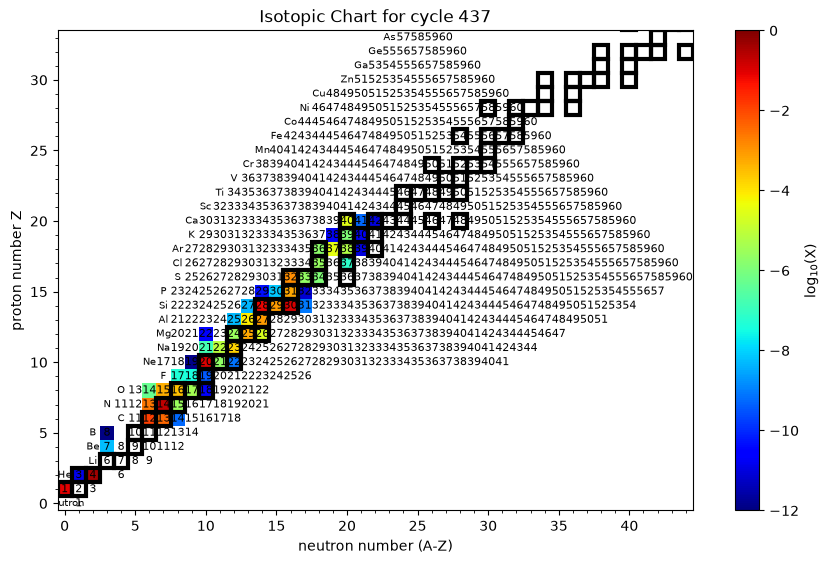

<Figure size 900x700 with 0 Axes>

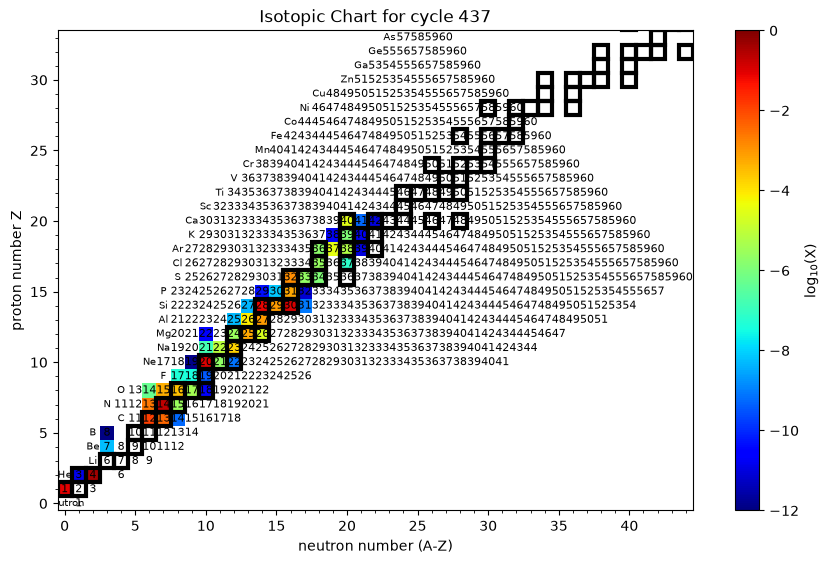

In [3]:
mpy.figure(figsize=(9, 7))
p.abu_chart(int(cycles[-1]), mass_range=[0, 60], boxstable=True, show=False)
mpy.gcf()


## 3. Flux chart

Reaction fluxes are read from `flux_NNNNN.DAT` in the run directory using a path
relative to the current working directory, so we `chdir` into the run first.


flux_00437.DAT
chart for nucleosynthesis fluxes [dYi/dt]
flux_00437.DAT  read!
plot range given by default


abundance-flux-chart437 is done


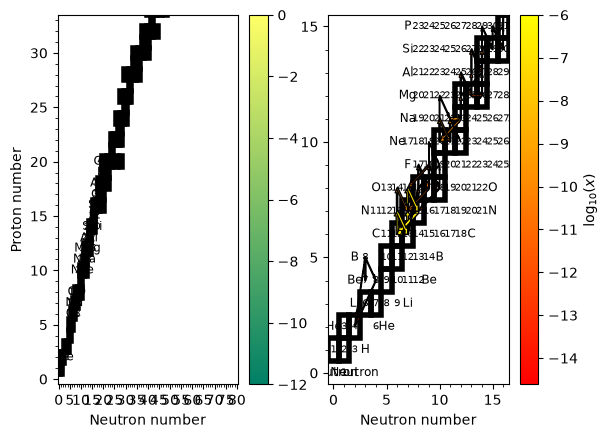

<Figure size 1100x600 with 0 Axes>

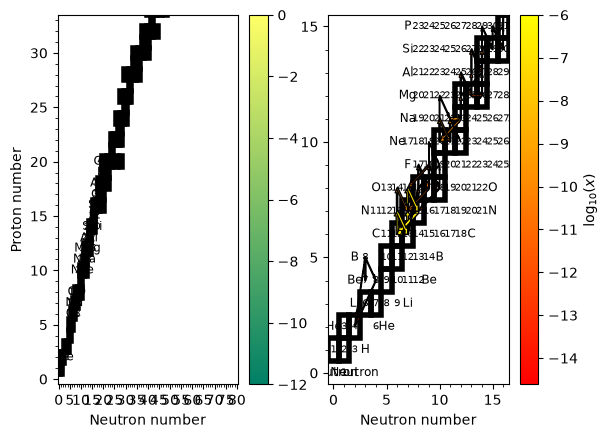

In [4]:
os.chdir(BASELINE_DIR)
mpy.figure(figsize=(11, 6))
p.abu_flux_chart(int(cycles[-1]), threshold=-6, show=False)
mpy.gcf()


## 4. Ratio chart: compare two cycles to find an interesting isotope

`abu_ratio_chart` is built to compare two *datasets* (e.g. a factored run against its
baseline, see Section 6), but nothing stops `other` from being the same instance at a
different cycle — which is exactly a two-cycle comparison of one run's own evolution.

We compare cycle 200 (well past the initial transient) to the final cycle 437, and
apply a `threshold` so isotopes that are still essentially at the numerical floor at
both cycles don't dominate the ranking with meaningless swings.


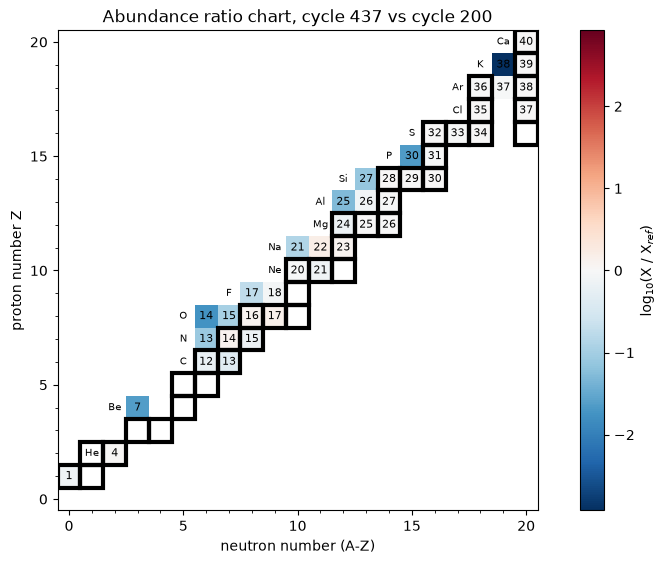

<Figure size 900x700 with 0 Axes>

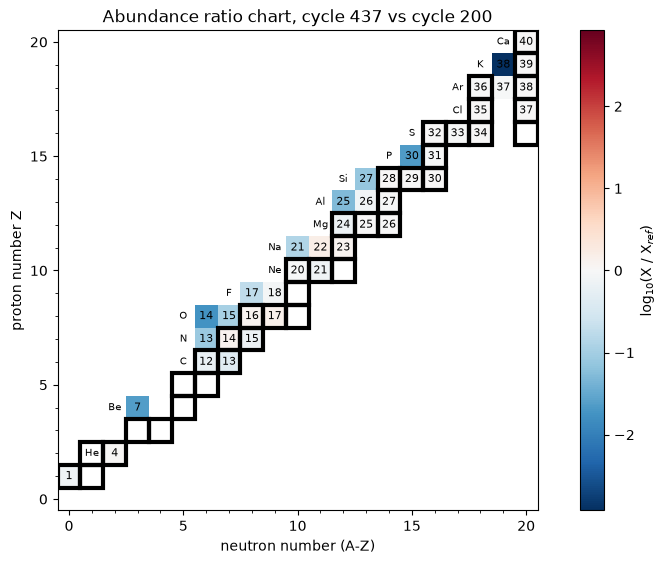

In [5]:
cycle_early, cycle_late = 200, int(cycles[-1])

mpy.figure(figsize=(9, 7))
ratios = p.abu_ratio_chart(p, cycle=cycle_late, other_cycle=cycle_early,
                            threshold=-8, mass_range=[0, 60], show=False)
mpy.gcf()


In [6]:
top = sorted(ratios.items(), key=lambda kv: abs(kv[1]), reverse=True)[:10]
print(f'Biggest abundance changes, cycle {cycle_early} -> {cycle_late}:')
for (n, z), log10ratio in top:
    print(f'  {p._isotope_name(n, z):>6s}   log10(X_late/X_early) = {log10ratio:+.3f}')


Biggest abundance changes, cycle 200 -> 437:
    K-38   log10(X_late/X_early) = -2.923
    O-14   log10(X_late/X_early) = -1.746
    P-30   log10(X_late/X_early) = -1.657
    Be-7   log10(X_late/X_early) = -1.629
   Al-25   log10(X_late/X_early) = -1.301
   Si-27   log10(X_late/X_early) = -1.139
    N-13   log10(X_late/X_early) = -1.094
    O-15   log10(X_late/X_early) = -0.961
   Na-21   log10(X_late/X_early) = -0.882
    F-17   log10(X_late/X_early) = -0.744


**Be-7** shows up clearly in that list (a real ~40x *decrease* from cycle 200 to 437 —
physically sensible, since Be-7 electron-captures to Li-7 with a 53-day half-life and
the ejecta is cooling well past peak burning by then). Let's use it as the worked
example for the rest of this notebook.


## 5. What reactions are in the network, as a whole?

`networksetup.txt` lists every reaction the run's network was built from, including
superseded duplicates (an older rate evaluation kept in the file but marked inactive
once a newer one replaced it) — `reactions_in_network(..., active_only=True)` keeps
only the preferred entry for each physical reaction.


In [7]:
networksetup_path = os.path.join(BASELINE_DIR, 'networksetup.txt')
reactions = network.parse_networksetup(networksetup_path, p.elements_names)

print('reaction rows in networksetup.txt (incl. superseded duplicates):', len(reactions))
print('active (preferred) reactions:', len(network.reactions_in_network(reactions, active_only=True)))


reaction rows in networksetup.txt (incl. superseded duplicates): 13600
active (preferred) reactions: 13505


## 6. What reactions affect Be-7 -- and what's their rate source?

`reactions_for_isotope` finds every reaction where the isotope appears as reactant,
projectile, or product. Each `Reaction` already carries its rate **source** label (the
evaluation NuPPN uses to evolve the abundance: VITAL, JINAC, NACRR, RVRSE, ...), which
is the extra piece requested for this notebook.


In [8]:
be7_z, be7_a = 4, 7  # Beryllium, Z=4
be7_reactions = network.reactions_for_isotope(reactions, z=be7_z, a=be7_a)

print(f'{len(be7_reactions)} reactions affect Be-7:\n')
for r in be7_reactions:
    reactant = r.reactant.name.strip()
    projectile = r.projectile.name.strip()
    product1 = r.product1.name.strip()
    product2 = r.product2.name.strip()
    print(f'  idx={r.index:<5d} source={r.source:<6s} type={r.reaction_type:<8s} '
          f'{reactant} + {projectile} -> {product1} + {product2}')


16 reactions affect Be-7:

  idx=4     source=VITAL  type=(v,v)    HE  4 + HE  3 -> BE  7 + OOOOO
  idx=5     source=VITAL  type=(+,g)    BE  7 + OOOOO -> LI  7 + OOOOO
  idx=7     source=VITAL  type=(p,g)    BE  7 + PROT -> B   8 + OOOOO
  idx=9     source=RVRSE  type=(g,p)    B   8 + OOOOO -> BE  7 + PROT
  idx=10    source=VITAL  type=(a,g)    BE  7 + HE  4 -> C  11 + OOOOO
  idx=136   source=JINAC  type=(a,g)    HE  3 + HE  4 -> BE  7 + OOOOO
  idx=141   source=JINAC  type=(a,n)    HE  4 + OOOOO -> BE  7 + NEUT
  idx=146   source=NACRR  type=(p,g)    LI  6 + PROT -> BE  7 + OOOOO
  idx=154   source=RVRSE  type=(p,n)    LI  7 + PROT -> BE  7 + NEUT
  idx=170   source=JINAC  type=(n,p)    BE  7 + NEUT -> LI  7 + PROT
  idx=171   source=JINAC  type=(n,a)    BE  7 + NEUT -> HE  4 + OOOOO
  idx=173   source=RVRSE  type=(g,p)    BE  7 + OOOOO -> LI  6 + PROT
  idx=175   source=RVRSE  type=(g,a)    BE  7 + OOOOO -> HE  3 + HE  4
  idx=176   source=RVRSE  type=(a,p)    BE  7 + HE  4 -> B  

## 7. Sensitivity: how much does Be-7 respond to these reactions' rate uncertainty?

Of Be-7's 16 structural reactions above, this particular sensitivity study happens to
have pre-computed rate-factored runs (`runs_VITAL/<reaction>/fact_<factor>/`, à la
Iliadis et al. 2002) for two of them: **3He(a,g)7Be** (a production channel) and
**7Be(p,g)8B** (a destruction channel). That's what `sensitivity.reaction_sensitivity`
and `sensitivity.plot_reaction_sensitivity` read directly -- no cross-referencing back
to the `networksetup.txt` index needed.


In [9]:
be7_factored_reactions = ['3He_ag_7Be', '7Be_pg_8B']

for rxn in be7_factored_reactions:
    reaction_dir = os.path.join(RUNS_ROOT, rxn)
    sens = sensitivity.reaction_sensitivity(BASELINE_DIR, reaction_dir, 'Be-7')
    print(rxn, {factor: round(ratio, 4) for factor, ratio in sorted(sens.items())})


23 cycle numbers found in /home/sgervais/Documents/NovaNucleosynthesis/NovaSensitivityStudy/single-zone/nova_cases/ne_nova_1.15_12_X_weiss_mixed/runs_VITAL/baseline
Ranging from 00000 to 00437
Range may not be continuous. To display all available cycles, print <abu_vector_instance>.files
23 cycle numbers found in /home/sgervais/Documents/NovaNucleosynthesis/NovaSensitivityStudy/single-zone/nova_cases/ne_nova_1.15_12_X_weiss_mixed/runs_VITAL/3He_ag_7Be/fact_0.5
Ranging from 00000 to 00437
Range may not be continuous. To display all available cycles, print <abu_vector_instance>.files
23 cycle numbers found in /home/sgervais/Documents/NovaNucleosynthesis/NovaSensitivityStudy/single-zone/nova_cases/ne_nova_1.15_12_X_weiss_mixed/runs_VITAL/3He_ag_7Be/fact_2
Ranging from 00000 to 00437
Range may not be continuous. To display all available cycles, print <abu_vector_instance>.files
3He_ag_7Be {0.5: np.float64(1.6955), 2.0: np.float64(0.3693)}
23 cycle numbers found in /home/sgervais/Documents/

23 cycle numbers found in /home/sgervais/Documents/NovaNucleosynthesis/NovaSensitivityStudy/single-zone/nova_cases/ne_nova_1.15_12_X_weiss_mixed/runs_VITAL/baseline
Ranging from 00000 to 00437
Range may not be continuous. To display all available cycles, print <abu_vector_instance>.files


23 cycle numbers found in /home/sgervais/Documents/NovaNucleosynthesis/NovaSensitivityStudy/single-zone/nova_cases/ne_nova_1.15_12_X_weiss_mixed/runs_VITAL/3He_ag_7Be/fact_0.5
Ranging from 00000 to 00437
Range may not be continuous. To display all available cycles, print <abu_vector_instance>.files
23 cycle numbers found in /home/sgervais/Documents/NovaNucleosynthesis/NovaSensitivityStudy/single-zone/nova_cases/ne_nova_1.15_12_X_weiss_mixed/runs_VITAL/3He_ag_7Be/fact_2
Ranging from 00000 to 00437
Range may not be continuous. To display all available cycles, print <abu_vector_instance>.files


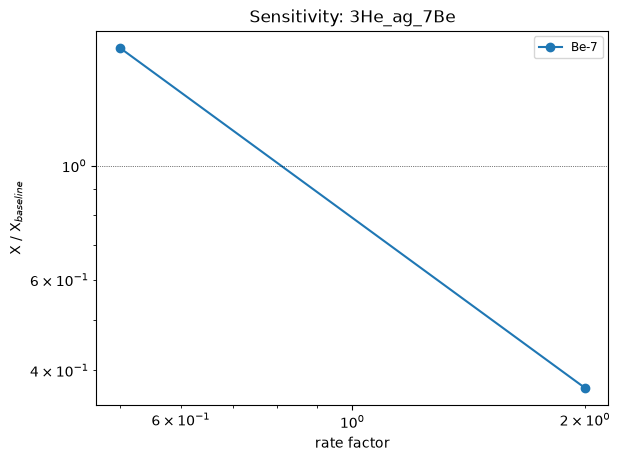

<Figure size 700x500 with 0 Axes>

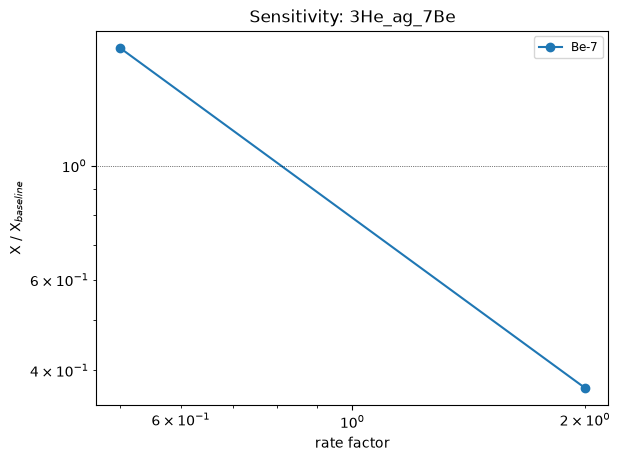

In [10]:
mpy.figure(figsize=(7, 5))
sensitivity.plot_reaction_sensitivity(BASELINE_DIR, os.path.join(RUNS_ROOT, '3He_ag_7Be'),
                                       ['Be-7'], show=False)
mpy.gcf()


23 cycle numbers found in /home/sgervais/Documents/NovaNucleosynthesis/NovaSensitivityStudy/single-zone/nova_cases/ne_nova_1.15_12_X_weiss_mixed/runs_VITAL/baseline
Ranging from 00000 to 00437
Range may not be continuous. To display all available cycles, print <abu_vector_instance>.files
23 cycle numbers found in /home/sgervais/Documents/NovaNucleosynthesis/NovaSensitivityStudy/single-zone/nova_cases/ne_nova_1.15_12_X_weiss_mixed/runs_VITAL/7Be_pg_8B/fact_0.5
Ranging from 00000 to 00437
Range may not be continuous. To display all available cycles, print <abu_vector_instance>.files
23 cycle numbers found in /home/sgervais/Documents/NovaNucleosynthesis/NovaSensitivityStudy/single-zone/nova_cases/ne_nova_1.15_12_X_weiss_mixed/runs_VITAL/7Be_pg_8B/fact_2
Ranging from 00000 to 00437
Range may not be continuous. To display all available cycles, print <abu_vector_instance>.files


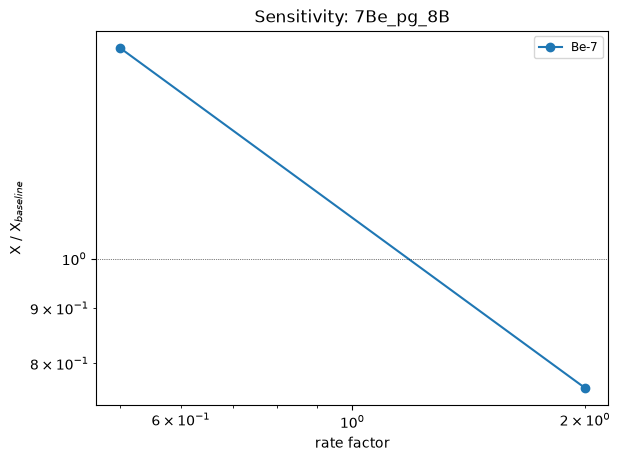

<Figure size 700x500 with 0 Axes>

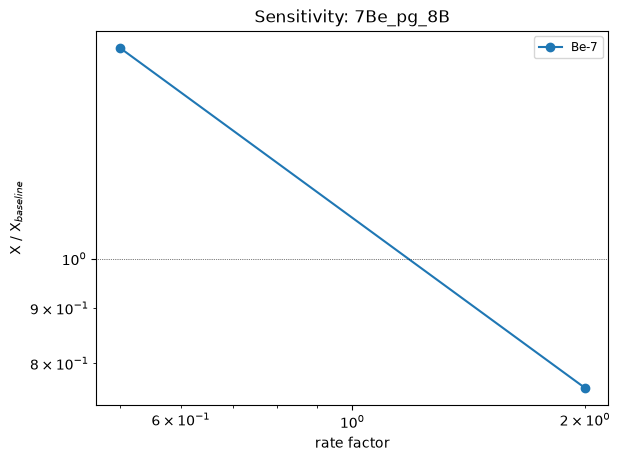

In [11]:
mpy.figure(figsize=(7, 5))
sensitivity.plot_reaction_sensitivity(BASELINE_DIR, os.path.join(RUNS_ROOT, '7Be_pg_8B'),
                                       ['Be-7'], show=False)
mpy.gcf()


Note the two reactions don't just differ in *how much* they move Be-7 -- for
`3He(a,g)7Be`, a larger production rate actually leaves *less* Be-7 at this cycle, the
opposite of the naively-expected direction. That's a real, non-trivial network-coupling
effect (this reaction also competes for He-3/He-4 with other pathways), not a bug in
the sensitivity calculation -- one-factor-at-a-time scans like this are exactly how you
find that a reaction's effect isn't as simple as "faster production = more product."

## Future work: reaction rate vs. temperature

A natural next addition is plotting a reaction's actual rate as a function of T9
(temperature in GK) directly from the network's rate tables, rather than only the
abundance *response* to a fixed factor as done above. That needs read access to
`NPDATA` (the compiled rate-table data NuPPN's `frames/*/source` builds against), which
isn't wired up yet -- left as a follow-up feature.
